In [8]:
#load the dataset
import pandas as pd
import numpy as np

df = pd.read_csv('preprocessed_network_dataset.csv')

df.head()

,duration,src_bytes,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,...,http_method_POST,http_method_n/a,http_version_1.1,http_version_n/a,weird_addl_46,weird_addl_48,weird_addl_n/a,weird_notice_F,weird_notice_n/a,label
0,290.371539,101568,2592,0,108,108064,31,3832,0,0,...,False,True,False,True,False,False,True,False,True,1
1,0.000102,0,0,0,1,52,1,40,0,0,...,False,True,False,True,False,False,True,False,True,1
2,0.000148,0,0,0,1,52,1,40,0,0,...,False,True,False,True,False,False,True,False,True,1
3,0.000113,0,0,0,1,48,1,40,0,0,...,False,True,False,True,False,False,True,False,True,1
4,0.000130,0,0,0,1,52,1,40,0,0,...,False,True,False,True,False,False,True,False,True,1


In [9]:
print(df.info())

print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296868 entries, 0 to 296867
Data columns (total 90 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                296868 non-null  float64
 1   src_bytes               296868 non-null  int64  
 2   dst_bytes               296868 non-null  int64  
 3   missed_bytes            296868 non-null  int64  
 4   src_pkts                296868 non-null  int64  
 5   src_ip_bytes            296868 non-null  int64  
 6   dst_pkts                296868 non-null  int64  
 7   dst_ip_bytes            296868 non-null  int64  
 8   dns_query               296868 non-null  int64  
 9   dns_qclass              296868 non-null  int64  
 10  dns_qtype               296868 non-null  int64  
 11  dns_rcode               296868 non-null  int64  
 12  ssl_version             296868 non-null  int64  
 13  ssl_cipher              296868 non-null  int64  
 14  ssl_subject         

In [10]:
from sklearn.feature_selection import chi2, GenericUnivariateSelect

X = df.drop('label', axis=1)
X_res = X.astype(float)
y = df['label']

print(X_res.info())
print(X_res.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296868 entries, 0 to 296867
Data columns (total 89 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                296868 non-null  float64
 1   src_bytes               296868 non-null  float64
 2   dst_bytes               296868 non-null  float64
 3   missed_bytes            296868 non-null  float64
 4   src_pkts                296868 non-null  float64
 5   src_ip_bytes            296868 non-null  float64
 6   dst_pkts                296868 non-null  float64
 7   dst_ip_bytes            296868 non-null  float64
 8   dns_query               296868 non-null  float64
 9   dns_qclass              296868 non-null  float64
 10  dns_qtype               296868 non-null  float64
 11  dns_rcode               296868 non-null  float64
 12  ssl_version             296868 non-null  float64
 13  ssl_cipher              296868 non-null  float64
 14  ssl_subject         

In [11]:
print(y.info())
print(y.describe(include='all'))

<class 'pandas.core.series.Series'>
RangeIndex: 296868 entries, 0 to 296867
Series name: label
Non-Null Count   Dtype
--------------   -----
296868 non-null  int64
dtypes: int64(1)
memory usage: 2.3 MB
None
count    296868.000000
mean          0.500000
std           0.500001
min           0.000000
25%           0.000000
50%           0.500000
75%           1.000000
max           1.000000
Name: label, dtype: float64


Original number of features: 89
Reduced number of features: 69
['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'ssl_version', 'ssl_cipher', 'http_uri', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'proto_icmp', 'proto_tcp', 'proto_udp', 'service_dce_rpc', 'service_dns', 'service_ftp', 'service_gssapi', 'service_http', 'service_n/a', 'service_smb', 'service_ssl', 'conn_state_OTH', 'conn_state_REJ', 'conn_state_RSTO', 'conn_state_RSTR', 'conn_state_RSTRH', 'conn_state_S0', 'conn_state_S1', 'conn_state_S2', 'conn_state_S3', 'conn_state_SF', 'conn_state_SH', 'conn_state_SHR', 'dns_AA_F', 'dns_AA_T', 'dns_AA_n/a', 'dns_RD_F', 'dns_RD_T', 'dns_RD_n/a', 'dns_RA_F', 'dns_RA_T', 'dns_RA_n/a', 'dns_rejected_F', 'dns_rejected_T', 'dns_rejected_n/a', 'ssl_resumed_F', 'ssl_resume

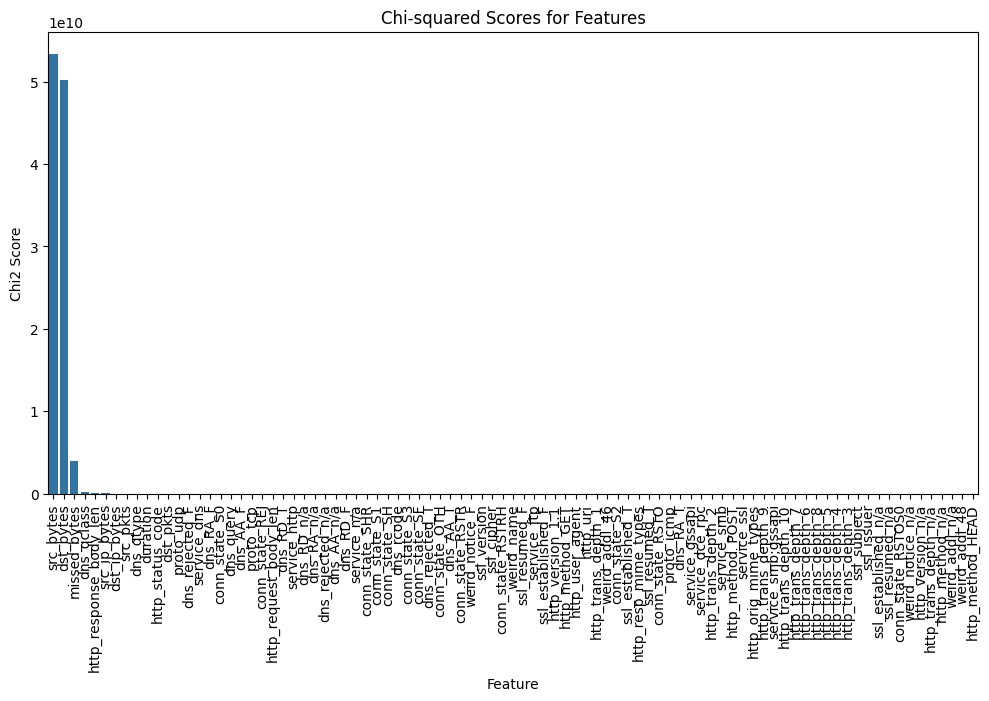

In [12]:
#apply chi-squared test and visualize the results
selector = GenericUnivariateSelect(chi2, mode='fpr')
X_new = selector.fit_transform(X_res, y)
print("Original number of features:", X_res.shape[1])
print("Reduced number of features:", X_new.shape[1])

selected_feature_names = X_res.columns[selector.get_support()].tolist()
print(selected_feature_names)
print(f"lenght of selected features list: {len(selected_feature_names)}")

# Display chi-squared scores for each feature
chi2_scores, p_values = chi2(X_res, y)
feature_names = X_res.columns
chi2_results = pd.DataFrame({'Feature': feature_names, 'Chi2 Score': chi2_scores, 'p-value': p_values})
chi2_results = chi2_results.sort_values(by='Chi2 Score', ascending=False)
print(chi2_results)


# Visualize chi-squared scores
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Chi2 Score', data=chi2_results)
plt.xticks(rotation=90)
plt.title('Chi-squared Scores for Features')
plt.show()


In [13]:
#save the selected features to a new CSV file
df_selected = pd.DataFrame(X_new, columns=X_res.columns[selector.get_support()])
df_selected['label'] = y.values
df_selected.to_csv('selected_features_network_dataset.csv', index=False)

In [14]:
#save feature names
import joblib

joblib.dump(selected_feature_names, 'selected_feature_names.pkl')

joblib.dump(selector, 'feature_selector.pkl')

print(f"Saved {len(selected_feature_names)} selected features")

Saved 69 selected features
